# Operações Espaciais Avançadas, Fiona e Estudo de Caso

### Fiona - leitura de dados geoespaciais

Fiona é uma **biblioteca Python** que faz interface com **OGR** (OpenGIS Simple Features Reference Implementation) a partir de dados vetoriais **GDAL** (Geospatial Data Abstraction Library).

Enquanto o GeoPandas é usado em análise o fiona é uma ferramenta para ler e escrever arquivos geoespaciais. Ou seja, ele é utilizado quando é necessário trabalhar com formatos que o GeoPandas não pode suportar bem.

In [10]:
!pip install fiona

In [11]:
import fiona

shp_path = "/content/saida/pontos_coleta.shp"

with fiona.open(shp_path) as src:
  print("Metadados da fonte")
  print(" Motor (drive):", src.driver)
  print(" CRS:", src.crs)
  print(" Número de feições:", len(src))
  print(" Extensão (bounds):", src.bounds)
  print("    Schema:")
  print("    Geometria:", src.schema["geometry"])
  print("    Propriedades:", src.schema["properties"])

Metadados da fonte
 Motor (drive): ESRI Shapefile
 CRS: 
 Número de feições: 6
 Extensão (bounds): (-46.66, -23.57, -46.62, -23.54)
    Schema:
    Geometria: Point
    Propriedades: {'id': 'int:18', 'data': 'str:80', 'parametro': 'str:80', 'valor': 'float:24.15', 'x': 'float:24.15', 'y': 'float:24.15'}


In [12]:
with fiona.open(shp_path) as src:
  print("=== Iterando sobre as feições ===\n")
  for i, feature in enumerate(src):
    print(f"Feição {i+1}:")
    print(f"   ID: {feature["id"]}")
    print(f"   Geometria: {feature["geometry"]["type"]}")
    print(f"   Coordenadas: {feature["geometry"]["coordinates"]}")
    print(f"   Propriedades: {feature["properties"]}")
    print()

=== Iterando sobre as feições ===

Feição 1:
   ID: 0
   Geometria: Point
   Coordenadas: (-46.63, -23.55)
   Propriedades: fiona.Properties(id=1, data='2024-01-15', parametro='pH', valor=6.8, x=-46.63, y=-23.55)

Feição 2:
   ID: 1
   Geometria: Point
   Coordenadas: (-46.64, -23.56)
   Propriedades: fiona.Properties(id=2, data='2024-01-15', parametro='turbidez', valor=12.3, x=-46.64, y=-23.56)

Feição 3:
   ID: 2
   Geometria: Point
   Coordenadas: (-46.65, -23.55)
   Propriedades: fiona.Properties(id=3, data='2024-01-15', parametro='pH', valor=7.1, x=-46.65, y=-23.55)

Feição 4:
   ID: 3
   Geometria: Point
   Coordenadas: (-46.62, -23.54)
   Propriedades: fiona.Properties(id=4, data='2024-01-16', parametro='oxigenio', valor=5.2, x=-46.62, y=-23.54)

Feição 5:
   ID: 4
   Geometria: Point
   Coordenadas: (-46.66, -23.57)
   Propriedades: fiona.Properties(id=5, data='2024-01-16', parametro='pH', valor=6.9, x=-46.66, y=-23.57)

Feição 6:
   ID: 5
   Geometria: Point
   Coordenadas: (-

Uma **feição** (feature) é a unidade fundamental do GIS vetorial: **geometria + atributos**.

### Fiona - Escrita de dados geoespaciais

É possível criar um arquivo geoespacial do zero com o Fiona, é só necessário definir:
* **schema** (tipo de geometria + propriedades)
* **crs**
* **feições** (geometria + atributos)

In [13]:
from shapely.geometry import Point, Polygon, mapping
import geopandas as gpd

schema = {
    "geometry": "Polygon",
    "properties": {
        "nome": "str",
        "area_km2": "float",
        "populacao": "int",
    }
}

bairros = [
    {
        "geometry": mapping(Polygon([(0, 0), (3, 0), (3, 3), (0, 3)])),
        "properties": {"nome": "Centro", "area_km2": 9.0, "populacao": 5000},
    },
    {
        "geometry": mapping(Polygon([(3, 0), (7, 0), (7, 3), (3, 3)])),
        "properties": {"nome": "Jardins", "area_km2": 12.0, "populacao": 3000},
    },
    {
        "geometry": mapping(Polygon([(0, 3), (3, 3), (3, 7), (0, 7)])),
        "properties": {"nome": "Industrial", "area_km2": 12.0, "populacao": 1500},
    },
    {
        "geometry": mapping(Polygon([(3, 3), (7, 3), (7, 7), (3, 7)])),
        "properties": {"nome": "Universitário", "area_km2": 16.0, "populacao": 8000},
    },
]

output_path = "saida/bairros.shp"

with fiona.open(
    output_path, "w",
    driver="ESRI Shapefile",
    schema=schema,
    crs="EPSG:4326",
) as dst:
  for bairro in bairros:
    dst.write(bairro)


print(f"Arquivo criado: {output_path}")

bairros_gdf = gpd.read_file(output_path)
bairros_gdf


Arquivo criado: saida/bairros.shp


,nome,area_km2,populacao,geometry
0,Centro,9.0,5000,"POLYGON ((0 0, 0 3, 3 3, 3 0, 0 0))"
1,Jardins,12.0,3000,"POLYGON ((3 0, 3 3, 7 3, 7 0, 3 0))"
2,Industrial,12.0,1500,"POLYGON ((0 3, 0 7, 3 7, 3 3, 0 3))"
3,Universitário,16.0,8000,"POLYGON ((3 3, 3 7, 7 7, 7 3, 3 3))"


O que a função `mapping()` faz? Ela **converte uma geometria Shapely para o formato GeoJSON-like** (dict) que a Fiona espera. Ou seja, é a ponte entre as duas bibliotecas.

### Spatial Join - Unindo dados pela localização

Um spatial join (`sjoin`) é como um JOIN de SQL, mas a condição de junçãoé espacial em vez de igualdade de chaves. Por exemplo: "Quais escolas estão dentro de cada bairro?"

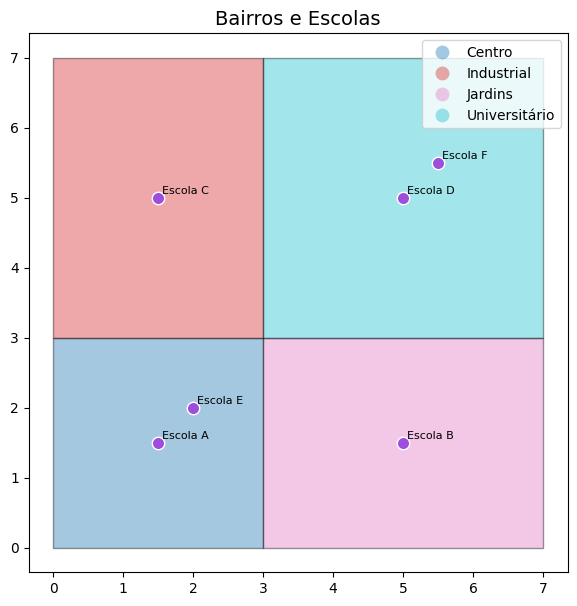

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

escolas = gpd.GeoDataFrame({
    "nome": ["Escola A", "Escola B", "Escola C", "Escola D", "Escola E", "Escola F"],
    "tipo": ["Municipal", "Estadual", "Municipal", "Estadual", "Municipal", "Particular"],
    "alunos": [300, 500, 200, 450, 350, 600],
    "geometry": [
      Point(1.5, 1.5),
      Point(5.0, 1.5),
      Point(1.5, 5.0),
      Point(5.0, 5.0),
      Point(2.0, 2.0),
      Point(5.5, 5.5),
    ]
}, crs="EPSG:4326")

fig, ax = plt.subplots(figsize=(7, 7))
bairros_gdf.plot(ax=ax, column="nome", alpha=0.4, edgecolor="black", legend=True)
escolas.plot(ax=ax, color="#9d4edd", markersize=80, edgecolor="white", linewidth=1)

for idx, row in escolas.iterrows():
  ax.text(row.geometry.x + 0.05, row.geometry.y + 0.05, row["nome"], fontsize=8)

ax.set_title("Bairros e Escolas", fontsize=14)
ax.set_aspect("equal")
plt.show()

In [15]:
escolas

,nome,tipo,alunos,geometry
0,Escola A,Municipal,300,POINT (1.5 1.5)
1,Escola B,Estadual,500,POINT (5 1.5)
2,Escola C,Municipal,200,POINT (1.5 5)
3,Escola D,Estadual,450,POINT (5 5)
4,Escola E,Municipal,350,POINT (2 2)
5,Escola F,Particular,600,POINT (5.5 5.5)


In [16]:
bairros_gdf

,nome,area_km2,populacao,geometry
0,Centro,9.0,5000,"POLYGON ((0 0, 0 3, 3 3, 3 0, 0 0))"
1,Jardins,12.0,3000,"POLYGON ((3 0, 3 3, 7 3, 7 0, 3 0))"
2,Industrial,12.0,1500,"POLYGON ((0 3, 0 7, 3 7, 3 3, 0 3))"
3,Universitário,16.0,8000,"POLYGON ((3 3, 3 7, 7 7, 7 3, 3 3))"


In [17]:
#unindo em um único dataframe todas as escolas que estão dentro de um bairro
escolas_por_bairro = gpd.sjoin(escolas,
                               bairros_gdf,
                               how="inner",
                               predicate="within",
                               lsuffix="left",
                               rsuffix="right"
                               )

escolas_por_bairro

,nome_left,tipo,alunos,geometry,index_right,nome_right,area_km2,populacao
0,Escola A,Municipal,300,POINT (1.5 1.5),0,Centro,9.0,5000
1,Escola B,Estadual,500,POINT (5 1.5),1,Jardins,12.0,3000
2,Escola C,Municipal,200,POINT (1.5 5),2,Industrial,12.0,1500
3,Escola D,Estadual,450,POINT (5 5),3,Universitário,16.0,8000
4,Escola E,Municipal,350,POINT (2 2),0,Centro,9.0,5000
5,Escola F,Particular,600,POINT (5.5 5.5),3,Universitário,16.0,8000


In [18]:
contagem = escolas_por_bairro.groupby("nome_right").agg(
    total_escolas=("nome_left", "count"),
    total_alunos=("alunos", "sum")
).reset_index()

contagem

,nome_right,total_escolas,total_alunos
0,Centro,2,650
1,Industrial,1,200
2,Jardins,1,500
3,Universitário,2,1050


In [19]:
contagem.columns = ["bairro", "total_escolas", "total_alunos"]
contagem

,bairro,total_escolas,total_alunos
0,Centro,2,650
1,Industrial,1,200
2,Jardins,1,500
3,Universitário,2,1050


Os parâmetros do `sjoin` são:

* **how** = é um tipo de join (como sql) que tem as opções `inner`, `left` e `right`.
* **predicate** = é a condição espacial de junção `intersects`, `within`, `contains`, `touches`, `crosses` e `overlaps`.
* **lsuffix** | **rsuffix** = eles são sufixos para colunas com mesmo nome e são strings



ps: quando o predicate é `within` ele vai encontrar as escolas dentro do bairro, e quando ele for `intersects` vai incluir as da fronteira também.

### Overlay - Sobreposição de camadas

Enquanto o `sjoin`transfere atributos entre camadas, o **overlay cria novas geometrias a partir da sobreposição**.

Uma boa comparação é que é como *aplicar as operações de conjuntos do Shapely em DataFrames inteiros*.

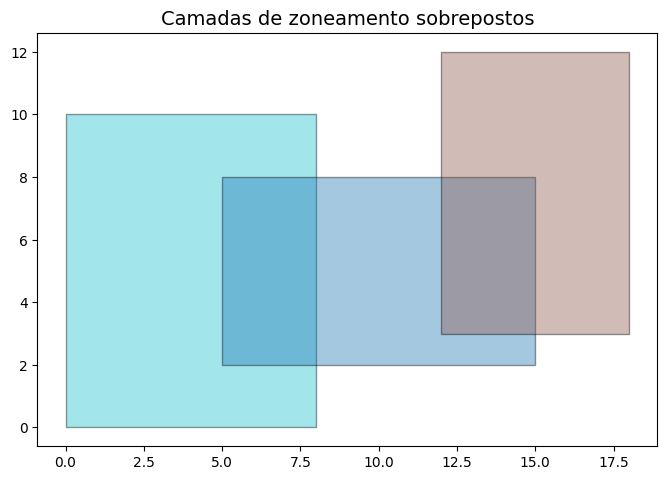

In [20]:
from shapely.geometry import box

zonas = gpd.GeoDataFrame({
    "zona": ["Residencial", "Comercial", "Parque"],
    "restricao": ["Altura máx 15m", "Altura máx 50m", "Construção proibida"],
    "geometry": [
        box(0, 0, 8, 10),
        box(5, 2, 15, 8),
        box(12, 3, 18, 12),
    ]
}, crs="EPSG:4326")

fig, ax = plt.subplots(figsize=(8, 6))
zonas.plot(ax=ax, column="zona", alpha=0.4, edgecolor="black")
ax.set_title("Camadas de zoneamento sobrepostos", fontsize=14)
ax.set_aspect("equal")
plt.show()

In [21]:
print(type(zonas.iloc[[0]]))

<class 'geopandas.geodataframe.GeoDataFrame'>


In [22]:
intersecao = gpd.overlay(
    zonas.iloc[[0]],
    zonas.iloc[[1]],
    how="intersection"
)

print("Interseção entre Residencial e Comercial:")
print(f"   Área total: {intersecao.to_crs(epsg=5880).area.sum():.2f}m²")
print(f"   Feições geradas: {len(intersecao)}")
intersecao

Interseção entre Residencial e Comercial:
   Área total: 342435930100.27m²
   Feições geradas: 1


,zona_1,restricao_1,zona_2,restricao_2,geometry
0,Residencial,Altura máx 15m,Comercial,Altura máx 50m,"POLYGON ((8 2, 5 2, 5 8, 8 8, 8 2))"


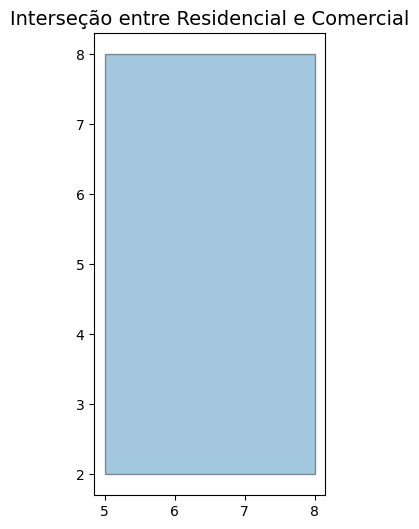

In [23]:
fig, ax = plt.subplots(figsize=(8, 6))
intersecao.plot(ax=ax, column="zona_1", alpha=0.4, edgecolor="black")
ax.set_title("Interseção entre Residencial e Comercial", fontsize=14)
ax.set_aspect("equal")
plt.show()

É importante destacar que antes de calcular a área em m² tive que modificar o CRS do GeoDataFrame para um que lida com metros como unidade de medida, pois como o **EPSG:4326** lida com longitudes e latitudes os resultados seriam incoerentes.

In [24]:
uniao = gpd.overlay(zonas.iloc[[0]], zonas.iloc[[1]], how="union")
print("União entre Residencial e Comercial:")
print(f"   Área total: {uniao.to_crs(epsg=5880).area.sum():.2f}m²")
print(f"   Feições geradas: {len(uniao)}")
uniao

União entre Residencial e Comercial:
   Área total: 2352083200218.71m²
   Feições geradas: 3


,zona_1,restricao_1,zona_2,restricao_2,geometry
0,Residencial,Altura máx 15m,Comercial,Altura máx 50m,"POLYGON ((8 2, 5 2, 5 8, 8 8, 8 2))"
1,Residencial,Altura máx 15m,NaN,NaN,"POLYGON ((8 0, 0 0, 0 10, 8 10, 8 8, 5 8, 5 2,..."
2,NaN,NaN,Comercial,Altura máx 50m,"POLYGON ((15 8, 15 2, 8 2, 8 8, 15 8))"


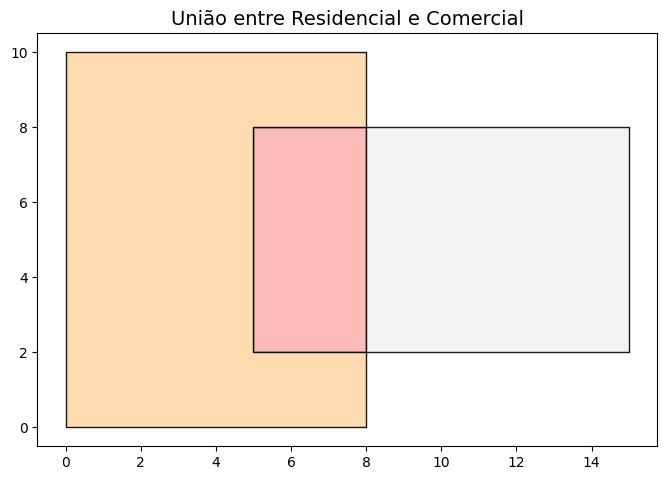

In [25]:
fig, ax = plt.subplots(figsize=(8, 6))
uniao.plot(ax=ax, alpha=0.9, edgecolor="black",
           cmap="Pastel1", missing_kwds={
            "color": "#e2a97e"})

ax.set_title("União entre Residencial e Comercial", fontsize=14)
ax.set_aspect("equal")
plt.show()

In [26]:
diferenca = gpd.overlay(zonas.iloc[[0]], zonas.iloc[[1]], how="difference")
print("Residencial menos Comercial:")
print(f"   Área restante: {diferenca.to_crs(epsg=5880).area.sum():.2f}")

diferenca

Residencial menos Comercial:
   Área restante: 1161040481052.72


,zona,restricao,geometry
0,Residencial,Altura máx 15m,"POLYGON ((8 0, 0 0, 0 10, 8 10, 8 8, 5 8, 5 2,..."


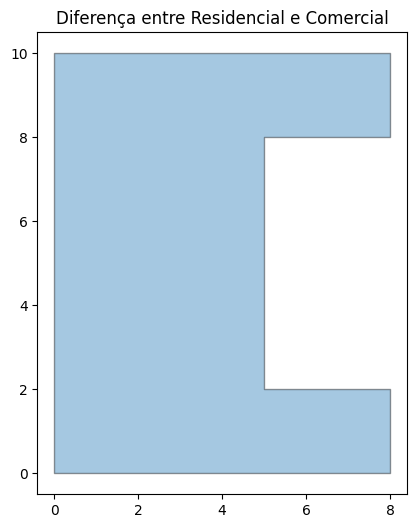

In [27]:
fig, ax = plt.subplots(figsize=(8, 6))
diferenca.plot(ax=ax, column="zona", alpha=0.4, edgecolor="black")
ax.set_title("Diferença entre Residencial e Comercial")
ax.set_aspect("equal")
plt.show()

Resumo das operações com overlay:

* `intersection` = área comum a duas camadas
* `union` = todas as áreas combinadas (pode gerar múltiplas geometrias)
* `difference` = área da primeira camada excluindo a segunda
* `symmetric_difference` = área exclusiva de cada camada
* `identity` = primeira camada com a adição de atributo das sobreposições com a segunda

### Transformação de CRS (`.to_crs()`)

Sabendo que:
* **EPSG:4326** usa graus e por isso não serve para medir área
* **EPSG:5641** é o sistema geodesico de referência, porém é expresso em graus
* **CRS projetados** (*UTM, SIRGAS 2000 / UTM, Albers*) usam metros e por isso permitem cálculos métricos precisos.

Portanto, é possível, e necessário, ***mudar de um CRS para outro para executar determinada atividade***.

ps: *sempre reprojete para um CRS plano (metros) antes de fazer buffer, calcular área ou distância*.

In [28]:
pts = gpd.GeoDataFrame({
    "nome": ["São Paulo", "Rio de Janeiro", "Brasília"],
    "geometry": [
        Point(-46.63, -23.55),
        Point(-43.20, -22.91),
        Point(-47.93, -15.78),
    ]
}, crs="EPSG:4326")

print("Coordenadas em WSG 84 (graus):")
for idx, row in pts.iterrows():
  print(f"   {row["nome"]}: x={row.geometry.x:.2f}, y={row.geometry.y:.2f}")


pts_utm = pts.to_crs("EPSG:31983")

print("Coordenadas em SIRGAS2000 UTM 23S (metros):")
for idx, row in pts_utm.iterrows():
  print(f"   {row["nome"]}: x={row.geometry.x:,.0f}m, y={row.geometry.y:,.0f}m")



Coordenadas em WSG 84 (graus):
   São Paulo: x=-46.63, y=-23.55
   Rio de Janeiro: x=-43.20, y=-22.91
   Brasília: x=-47.93, y=-15.78
Coordenadas em SIRGAS2000 UTM 23S (metros):
   São Paulo: x=333,624m, y=7,394,648m
   Rio de Janeiro: x=684,610m, y=7,465,314m
   Brasília: x=186,057m, y=8,253,215m


É possível desenhar buffers ao redor das geometrias do GeoDataFrame utilizando a função buffer, a partir de uma distância determinada.

Buffer de 100km no CRS projetado:
  Raio exato: 100,000m


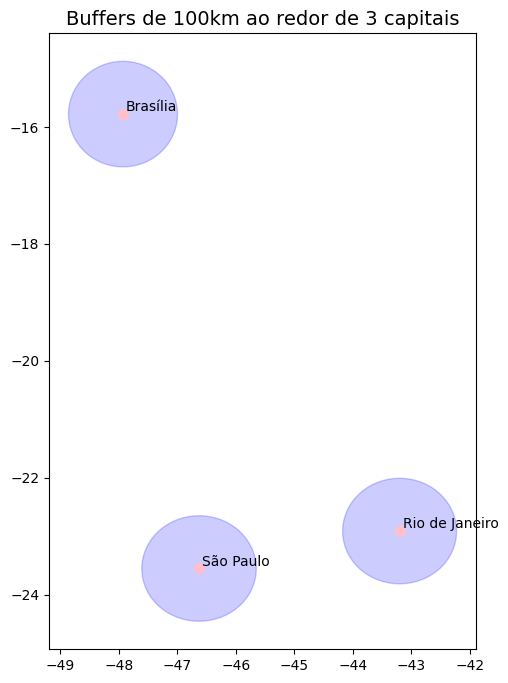

In [29]:
#para utilizar a função buffer é necessário que o crs use unidades métricas
print("Buffer de 100km no CRS projetado:")
buf = pts_utm.buffer(100000)
print(f"  Raio exato: 100,000m")

buf_geo = buf.to_crs("EPSG:4326")

fig, ax = plt.subplots(figsize=(10, 8))
buf_geo.plot(ax=ax, alpha=0.2, color="blue", edgecolor="blue")
pts.plot(ax=ax, alpha=1, color="pink", markersize=50)

for idx, row in pts.iterrows():
  ax.text(row.geometry.x + 0.05, row.geometry.y + 0.05, row["nome"], fontsize=10)

ax.set_title("Buffers de 100km ao redor de 3 capitais", fontsize=14)
ax.set_aspect("equal")
plt.show()

### Operação **dissolve** para agregação espacial

A operação **dissolve une geometrias vizinhas que compartilham um mesmo valor de atributo**. Exemplo de quando usar: *dissolver municípios para criar o polígono do estado*.

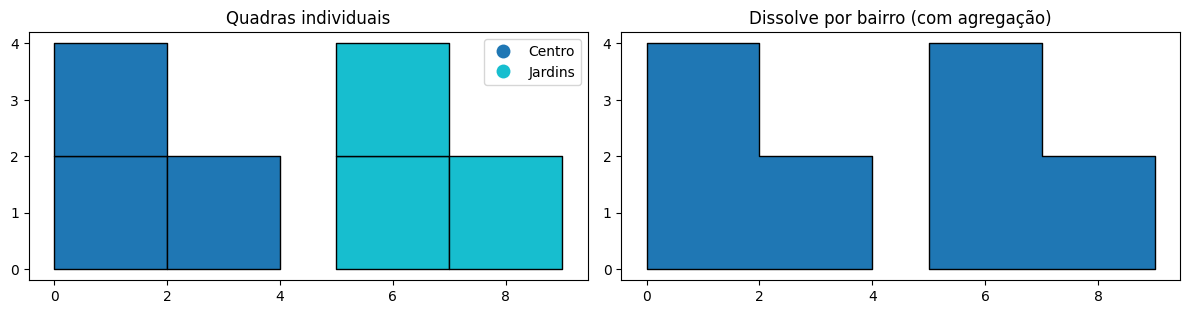

,geometry,populacao
bairro,,
Centro,"POLYGON ((0 0, 0 2, 0 4, 2 4, 2 2, 4 2, 4 0, 2...",450
Jardins,"POLYGON ((5 0, 5 2, 5 4, 7 4, 7 2, 9 2, 9 0, 7...",950


In [30]:
quadras = gpd.GeoDataFrame({
    "id": [1, 2, 3, 4, 5, 6],
    "bairro": ["Centro", "Centro", "Centro", "Jardins", "Jardins", "Jardins"],
    "populacao": [100, 200, 150, 300, 250, 400],
    "geometry": [
        box(0, 0, 2, 2),
        box(2, 0, 4, 2),
        box(0, 2, 2, 4),
        box(5, 0, 7, 2),
        box(7, 0, 9, 2),
        box(5, 2, 7, 4),
    ]
}, crs="EPSG:4326")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

quadras.plot(ax=axes[0], column="bairro", edgecolor="black", legend=True)
axes[0].set_title("Quadras individuais")
axes[0].set_aspect("equal")

bairros_dissolvidos = quadras.dissolve(by="bairro", aggfunc="sum")
bairros_dissolvidos.plot(ax=axes[1], edgecolor="black", legend=True)
axes[1].set_title("Dissolve por bairro (com agregação)")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()

bairros_dissolvidos[["geometry", "populacao"]]


In [31]:
quadras

,id,bairro,populacao,geometry
0,1,Centro,100,"POLYGON ((2 0, 2 2, 0 2, 0 0, 2 0))"
1,2,Centro,200,"POLYGON ((4 0, 4 2, 2 2, 2 0, 4 0))"
2,3,Centro,150,"POLYGON ((2 2, 2 4, 0 4, 0 2, 2 2))"
3,4,Jardins,300,"POLYGON ((7 0, 7 2, 5 2, 5 0, 7 0))"
4,5,Jardins,250,"POLYGON ((9 0, 9 2, 7 2, 7 0, 9 0))"
5,6,Jardins,400,"POLYGON ((7 2, 7 4, 5 4, 5 2, 7 2))"


In [32]:
bairros_dissolvidos

,geometry,id,populacao
bairro,,,
Centro,"POLYGON ((0 0, 0 2, 0 4, 2 4, 2 2, 4 2, 4 0, 2...",6,450
Jardins,"POLYGON ((5 0, 5 2, 5 4, 7 4, 7 2, 9 2, 9 0, 7...",15,950


In [33]:
print("População total por bairro (agregada via dissolve):")
print(bairros_dissolvidos["populacao"])

print("Número de quadras por bairro:")
bairros_contados = quadras.dissolve(by="bairro", aggfunc="count")
print(bairros_contados[["id"]])

População total por bairro (agregada via dissolve):
bairro
Centro     450
Jardins    950
Name: populacao, dtype: int64
Número de quadras por bairro:
         id
bairro     
Centro    3
Jardins   3


Os dois principais parâmetros da função dissolve são:

* `by` = qual coluna será usada para agrupar
* `aggfunc` = é a função de agregação, sendo as opções `sum`, `mean`, `first` ou `count`.

ps: *em casos que o `by` não é informado a função une todas as geometrias em uma só.*

### Trabalhando com dados reais

In [34]:
!pip install geobr

In [35]:
import geobr

geobr.list_geobr()

,Function,geography,source,alias,years_available
0,read_country,Country,IBGE,country,"1872, 1900, 1911, 1920, 1933, 1940, 1950, 1960..."
1,read_region,Region,IBGE,regions,"1872, 1900, 1911, 1920, 1933, 1940, 1950, 1960..."
2,read_state,States,IBGE,states,"1872, 1900, 1911, 1920, 1933, 1940, 1950, 1960..."
3,read_meso_region,Meso region,IBGE,mesoregions,"2000, 2001, 2013, 2014, 2015, 2016, 2017, 2018..."
4,read_micro_region,Micro region,IBGE,microregions,"2000, 2001, 2013, 2014, 2015, 2016, 2017, 2018..."
5,read_intermediate_region,Intermediate region,IBGE,intermediateregions,"2019, 2020, 2021, 2022, 2023, 2024, 2025"
6,read_immediate_region,Immediate region,IBGE,immediateregions,"2019, 2020, 2021, 2022, 2023, 2024, 2025"
7,read_municipality,Municipality,IBGE,municipalities,"1872, 1900, 1911, 1920, 1933, 1940, 1950, 1960..."
8,read_municipal_seat,Municipality seats,IBGE,municipalseats,"1872, 1900, 1911, 1920, 1933, 1940, 1950, 1960..."
9,read_weighting_area,Census weighting area,IBGE,weightingareas,"2010, 2022"


In [36]:
mun = geobr.read_municipality(code_muni=2306553, year="2025");
mun

,code_muni,name_muni,code_state,abbrev_state,name_state,code_region,name_region,year,geometry
0,2306553.0,Itarema,23.0,CE,Ceará,2.0,Nordeste,2025.0,"POLYGON ((-39.9962 -3.188, -39.98859 -3.17973,..."


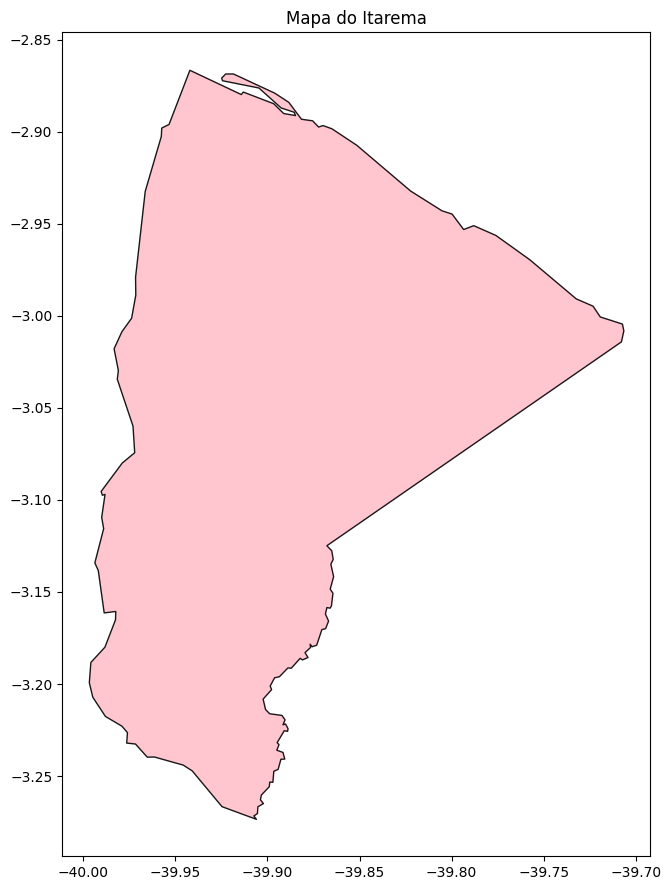

In [48]:
fig, ax = plt.subplots(figsize=(8, 9))

mun.plot(ax=ax, alpha=0.9, color="pink", edgecolor="black")
ax.set_title("Mapa do Itarema")
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

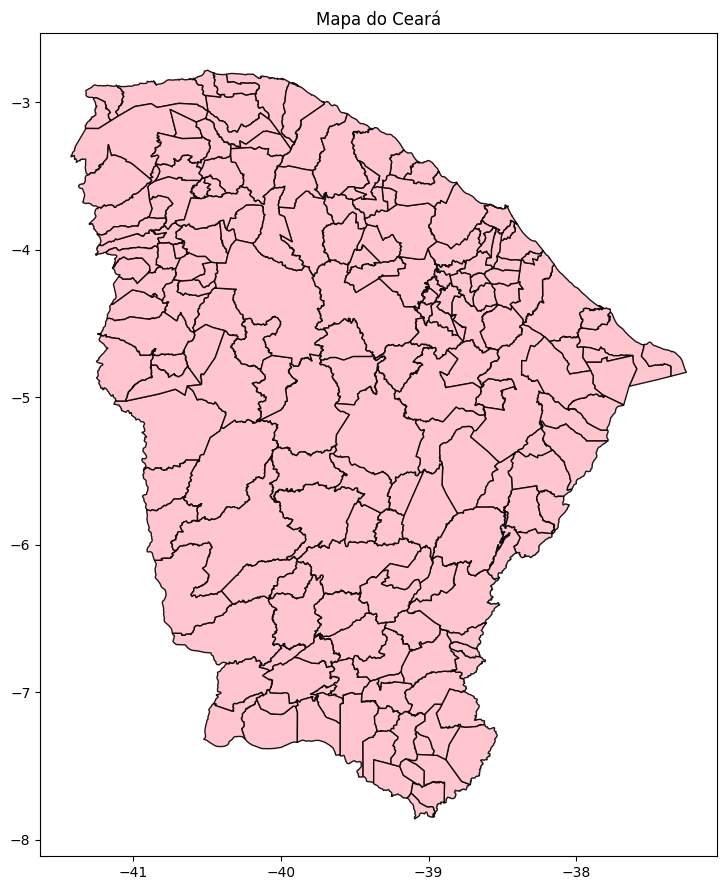

In [47]:
#plotando todas as cidades do ceará

ce_cidades = geobr.read_municipality(code_muni=23, year="2025")

fig, ax = plt.subplots(figsize=(8, 9))

ce_cidades.plot(ax=ax, alpha=0.9, color="pink", edgecolor="black")
ax.set_title("Mapa do Ceará")
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

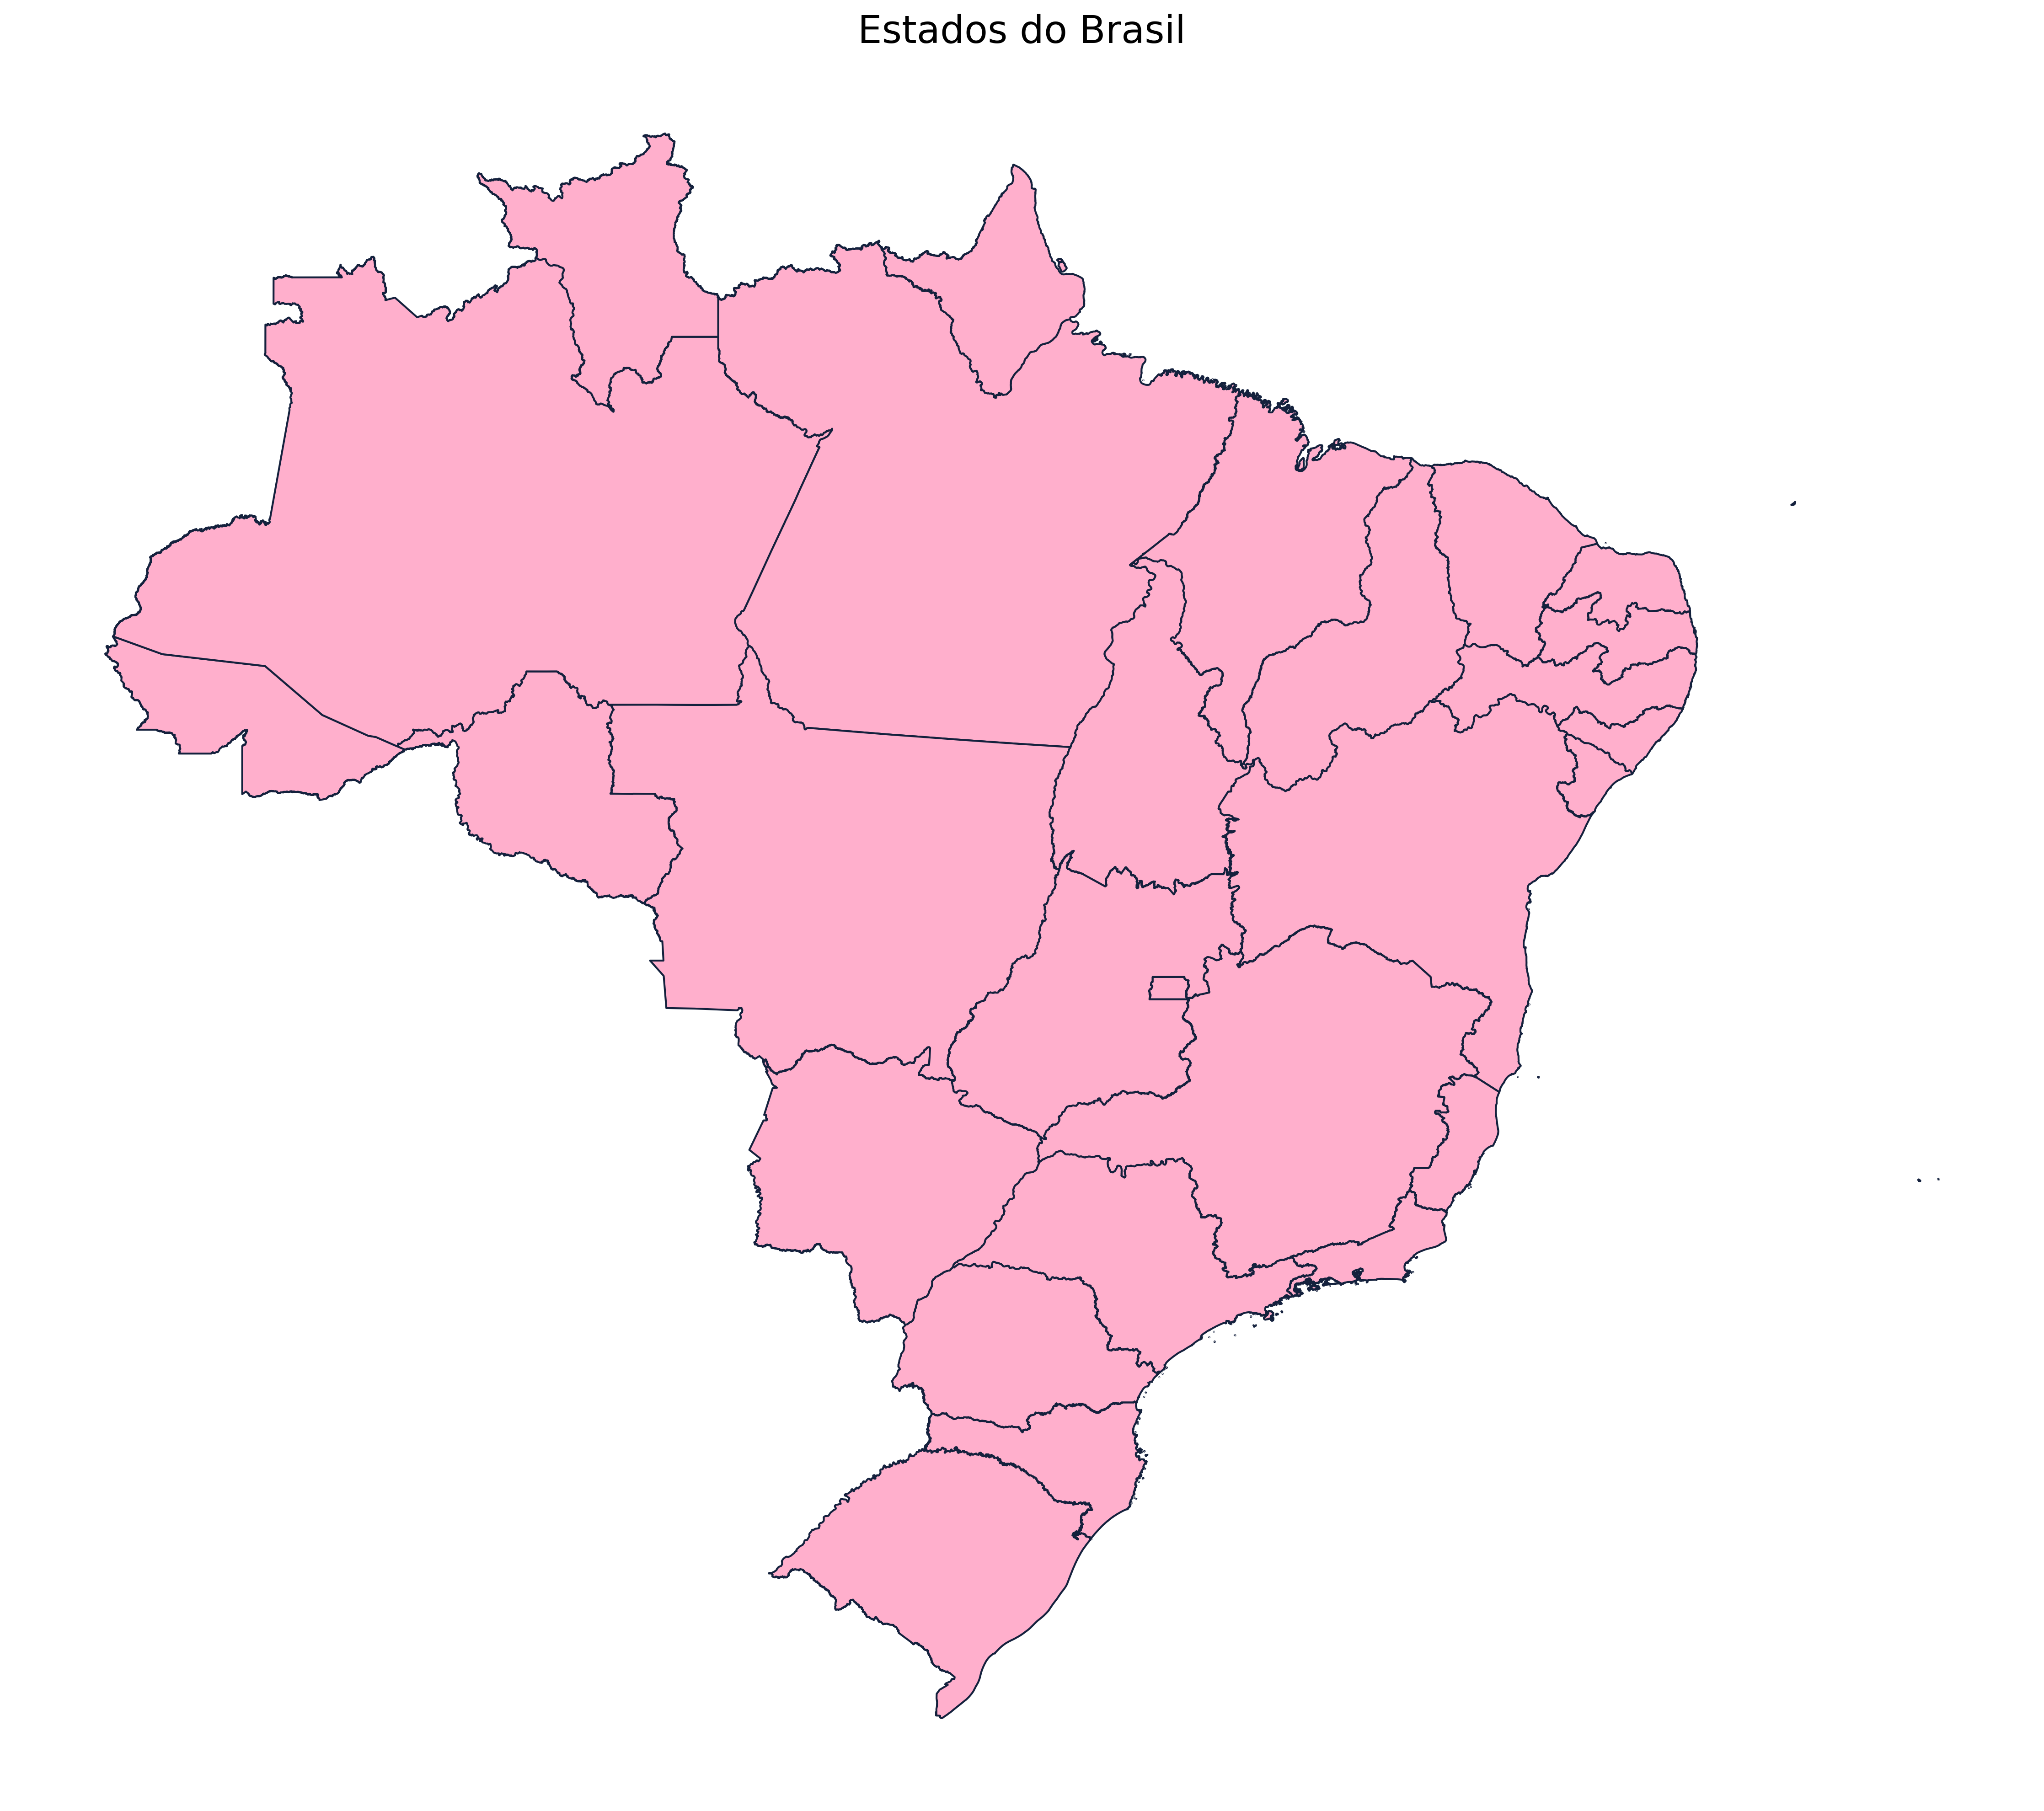

In [52]:
estados = geobr.read_state(year=2025)

fig, ax = plt.subplots(figsize=(15, 15), dpi=300)
estados.plot(facecolor="#ffafcc", edgecolor="#14213d", ax=ax)
ax.set_title("Estados do Brasil", fontsize=20)
ax.axis("off")
ax.set_aspect("equal")


plt.tight_layout()
plt.show()

Como unir os dados do município com os dados de saúde no estado de São Paulo?

In [103]:
#todos os municipios de são paulo
municipios = geobr.read_municipality(code_muni=35, year=2025)
municipios.head()

,code_muni,name_muni,code_state,abbrev_state,name_state,code_region,name_region,year,geometry
0,3500105.0,Adamantina,35.0,SP,São Paulo,3.0,Sudeste,2025.0,"POLYGON ((-51.14972 -21.7232, -51.14688 -21.71..."
1,3500204.0,Adolfo,35.0,SP,São Paulo,3.0,Sudeste,2025.0,"POLYGON ((-49.61249 -21.2611, -49.59711 -21.27..."
2,3500303.0,Aguaí,35.0,SP,São Paulo,3.0,Sudeste,2025.0,"POLYGON ((-46.88594 -22.07779, -46.89218 -22.0..."
3,3500402.0,Águas da Prata,35.0,SP,São Paulo,3.0,Sudeste,2025.0,"POLYGON ((-46.64421 -21.97455, -46.63747 -21.9..."
4,3500501.0,Águas de Lindóia,35.0,SP,São Paulo,3.0,Sudeste,2025.0,"POLYGON ((-46.58086 -22.51264, -46.58433 -22.5..."


<Axes: >

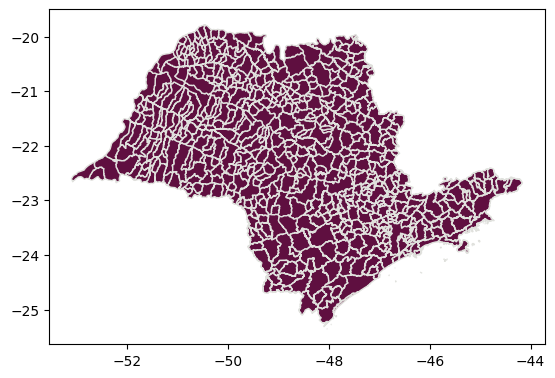

In [58]:
municipios.plot(color="#5f0f40", edgecolor="#e0e1dd")

In [102]:
dados_postos = geobr.read_health_facilities(
    202604,
    code_muni=35
)
dados_postos

/usr/local/lib/python3.13/dist-packages/shapely/io.py:352: RuntimeWarning: invalid value encountered in from_wkb
  return lib.from_wkb(geometry, invalid_handler, **kwargs)


,code_muni,name_muni,co_unidade,co_cnes,nu_cnpj_mantenedora,tp_pfpj,nivel_dep,no_razao_social,no_fantasia,logradouro,...,lat_cnes,lon_cnes,lat_geocodebr,lon_geocodebr,precisao_geocodebr,tipo_resultado_geocodebr,desvio_metros_geocodebr,coords_source,date_update,geometry
0,3500105.0,Adamantina,3500100047406,0047406,,3,1,GRAZIELE DAVID PSICOLOGA EIRELI,GRAZIELE DAVID PSICOLOGA EIRELI,RUA SCHIMIDT VILELA,...,-21.691097,-51.071137,-21.692354,-51.074063,cep,dc01,536,cnes,202604,POINT (-51.07114 -21.6911)
1,3500105.0,Adamantina,3500100081655,0081655,,3,1,RUFINO PRESTES LTDA,RUFINO PRESTES LTDA,AVENIDA RIO BRANCO,...,-21.690030,-51.071899,-21.690074,-51.071975,numero,dn03,6,cnes,202604,POINT (-51.0719 -21.69003)
2,3500105.0,Adamantina,3500100109789,0109789,,3,1,JOANA DARC BORRO,JOANA DARC BORRO,ALAMEDA JOAO ANDRADE,...,-21.692703,-51.071631,-21.692747,-51.071684,numero,dn01,6,cnes,202604,POINT (-51.07163 -21.6927)
3,3500105.0,Adamantina,3500100109827,0109827,,3,1,LAIS DANIEL FERREIRA,LAIS DANIEL FERREIRA,ALAMEDA FERNAO DIAS,...,-21.687400,-51.071006,-21.687351,-51.070871,numero,dn01,14,cnes,202604,POINT (-51.07101 -21.6874)
4,3500105.0,Adamantina,3500100183555,0183555,,3,1,MATEUS FERNANDO DA SILVA,MATEUS FERNANDO DA SILVA,AVENIDA ADHEMAR DE BARROS,...,-21.687584,-51.070090,-21.687468,-51.070186,numero,dn01,17,cnes,202604,POINT (-51.07009 -21.68758)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149528,3557303.0,Estiva Gerbi,3557306811507,6811507,67168856000141,3,3,PREFEITURA MUNICIPAL DE ESTIVA GERBI,CEM CENTRO DE ESPECIALIDADES MEDICAS,MARIO ZARA,...,-22.273808,-46.945567,-22.272111,-46.944775,localidade,db01,180,cnes,202604,POINT (-46.94557 -22.27381)
149529,3557303.0,Estiva Gerbi,3557306836542,6836542,67168856000141,3,3,PREFEITURA MUNICIPAL DE ESTIVA GERBI,ESPACO MAIS SAUDE RONALDO MARCIANO DE SOUZA,AVENIDA ADELIA CALEFI GERBI,...,-22.272021,-46.946983,-22.271187,-46.951564,numero_aproximado,pa02,6,cnes,202604,POINT (-46.94698 -22.27202)
149530,3557303.0,Estiva Gerbi,3557307047533,7047533,67168856000141,3,3,PREFEITURA MUNICIPAL DE ESTIVA GERBI,SAMU UNIDADE DE SUPORTE BASICO DE ESTIVA GERBI,TRAVESSA DANIEL DOS SANTOS,...,-22.275793,-46.952133,-22.269434,-46.950957,cep,dc02,5134,cnes,202604,POINT (-46.95213 -22.27579)
149531,3557303.0,Estiva Gerbi,3557307758561,7758561,,3,1,CLINICA DE DEPENDENTES QUINICOS MARCEL E FENIX...,CLINICA VILA FENIX,RODOVIA DEPUTADO MARIO BENI,...,-22.271000,-46.945000,-22.248495,-46.968350,cep,dc01,13,geocodebr,202604,POINT (-46.96835 -22.2485)


In [104]:
#checando quanta memoria RAM os dois geodatasets estão consumindo

import os
import psutil

def ram_usage():
  process = psutil.Process(os.getpid())
  ram = process.memory_info().rss / 1024**3
  print(f"RAM usage: {ram:.2f} GB")

ram_usage()

RAM usage: 2.56 GB


É importante destacar que em mapas/geopandas os dados dos geodataframes precisam estar no mesmo sistema de coordenadas para serem sobrepostos corretamente, por essa razão é sempre bom verificar se eles tem o mesmo crs.

In [105]:
municipios.crs == dados_postos.crs

True

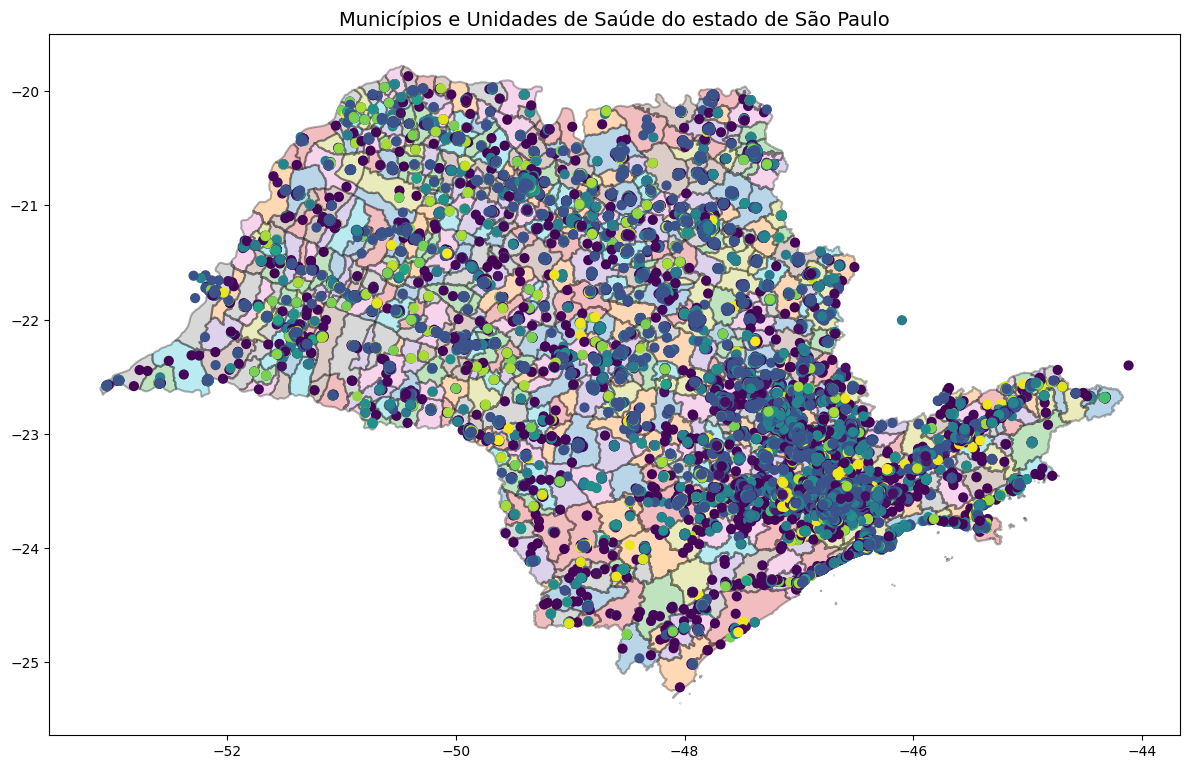

In [106]:
fig, ax = plt.subplots(figsize=(12, 10))
municipios.plot(ax=ax,
                column="name_muni",
                alpha=0.3,
                edgecolor="black",
                linewidth=1.5,
                legend=False)

dados_postos.plot(ax=ax,
                  column="tp_unidade",
                  markersize=40,
                  legend=False,
                  )

ax.set_title("Municípios e Unidades de Saúde do estado de São Paulo", fontsize=14)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

Observa-se que existem alguns pontos fora do estado, para corrigir isso será realizado um join espacial com os dois geodataframes.

In [114]:
estado_completo = municipios.dissolve()
#retornando apenas as geometrias do dados_postos que também estão em municipios
gdf_info_saude = gpd.sjoin(
    dados_postos,
    estado_completo,
    how="inner",
    predicate="within"
)


#retornando os pontos que estão fora do estado
gdf_out_sp = dados_postos.loc[~dados_postos.index.isin(gdf_info_saude.index)]
print(f"A quantidade de pontos fora do estado é: {gdf_out_sp.shape[0]}")

A quantidade de pontos fora do estado é: 41


<Axes: >

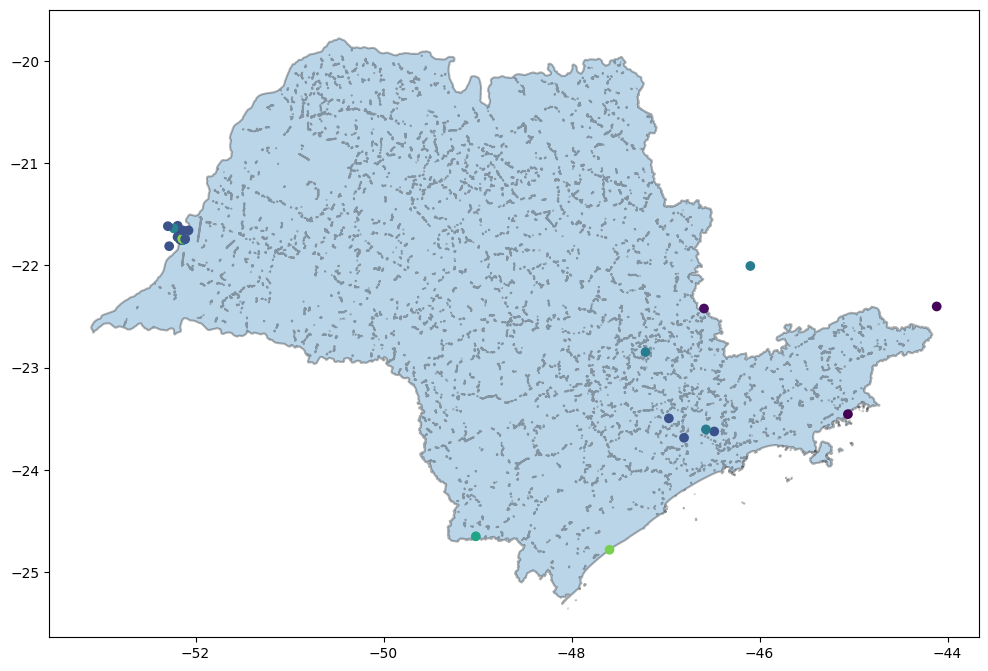

In [117]:
fig, ax = plt.subplots(figsize=(12, 10))
estado_completo.plot(ax=ax,
          column="name_muni",
          alpha=0.3,
          edgecolor="black",
          linewidth=1.5,
          legend=False)
gdf_out_sp.plot(ax=ax, column="tp_unidade")

Quantas unidades de saúde tem por município?

In [122]:
resumo = gdf_info_saude.groupby(["name_muni_left"]).agg(
    total_unidades=("co_unidade", "count"),
).reset_index()

print(resumo.to_string(index=False))
print(f"Total de unidades de saúde: {resumo["total_unidades"].sum()}")

            name_muni_left  total_unidades
                Adamantina             297
                    Adolfo               7
                     Aguaí              99
                    Agudos              67
                  Alambari              12
         Alfredo Marcondes              12
                    Altair              10
               Altinópolis              68
               Alto Alegre               8
                  Alumínio              25
               Alvinlândia               3
                 Americana            1365
                    Amparo             442
       Américo Brasiliense              50
         Américo de Campos              19
                 Analândia               9
                 Andradina             424
                  Angatuba              71
                   Anhembi              16
                   Anhumas              12
                 Aparecida              63
         Aparecida d'Oeste               8
           

# Exercicio

Crie um mapa que demonstra o número de unidades de saude por município de são paulo.

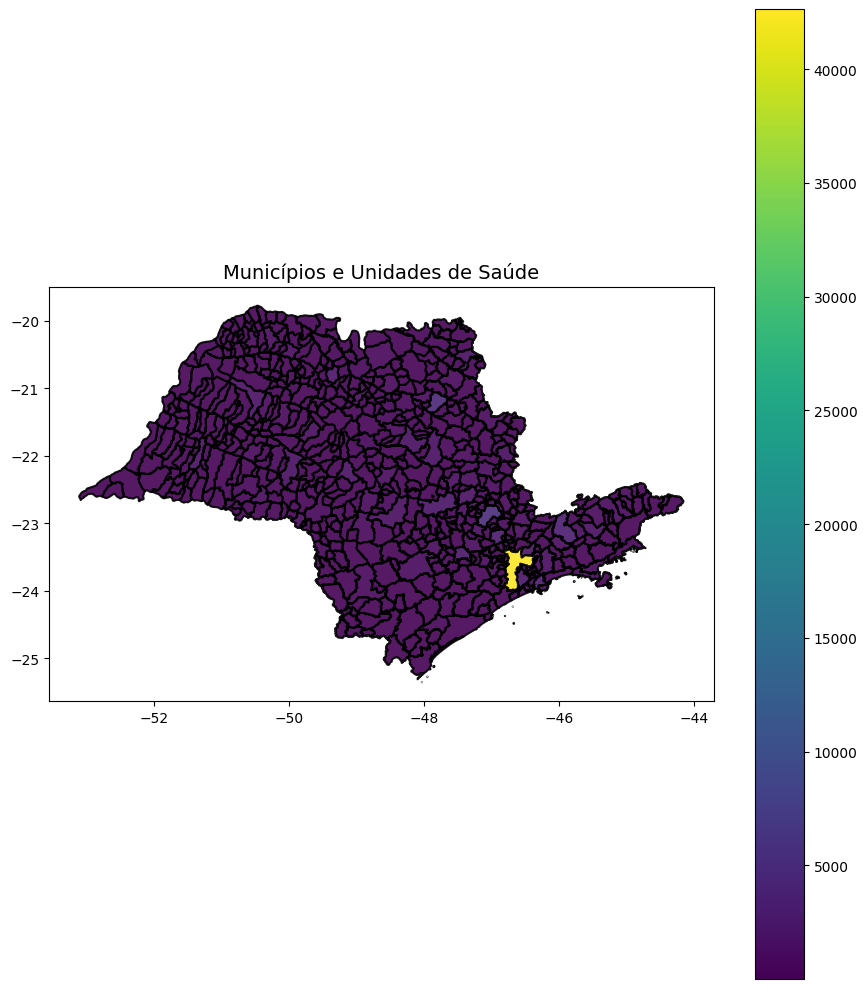

In [153]:
municipios_unidades = municipios.join(
    resumo.set_index("name_muni_left"),
    how="inner",
    on="name_muni"
)

municipios_unidades["total_unidades"].max()

fig, ax = plt.subplots(figsize=(9, 10))

municipios_unidades.plot(ax=ax,
                         column="total_unidades",
                         alpha=0.9,
                         edgecolor="black",
                         linewidth=1.5,
                         legend=True)

ax.set_title("Municípios e Unidades de Saúde", fontsize=14)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()